# RMR Dataset Generator

generating synthetic tunnel dataset — RMR89 based, with span/depth/method as extra inputs

targets: RMR score, rock class, bolt density, bolt length, shotcrete thickness

main references:
- Bieniawski 1989 (classification + support tables)
- Lowson & Bieniawski 2013 (bolt length vs span)
- Rehman et al. 2018 (shotcrete scaling)
- Hoek & Marinos 2000 (squeezing)
- Barton et al. 1974 (TBM correction)


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

from sklearn.metrics import confusion_matrix

SEED = 42
np.random.seed(SEED)

CLASS_ORDER = ['I', 'II', 'III', 'IV', 'V']
CLASS_COLORS = {'I':'#2ecc71', 'II':'#3498db', 'III':'#f39c12', 'IV':'#e67e22', 'V':'#e74c3c'}


## 1. RMR89 Rating Functions

straight lookup from Bieniawski Table 2 — nothing clever, just the rating scales


In [35]:
def ucs_rating(u):
    # param 1, max 15 pts
    if u > 250: return 15
    elif u > 100: return 12
    elif u > 50: return 7
    elif u > 25: return 4
    elif u > 5: return 2
    else: return 1

def rqd_rating(r):
    # param 2, max 20 pts
    if r >= 90: return 20
    elif r >= 75: return 17
    elif r >= 50: return 13
    elif r >= 25: return 8
    else: return 3
        
def js_rating(s):
    # joint spacing, param 3
    if s > 2: return 20
    elif s > 0.6: return 15
    elif s > 0.2: return 10
    elif s > 0.06: return 8
    else: return 5

JC_MAP = {1: 30, 2: 25, 3: 20, 4: 10, 5: 0}  # joint condition
GW_MAP = {1: 15, 2: 10, 3: 7,  4: 4,  5: 0}  # groundwater
ORIENT_VALUES = [0, -2, -5, -10, -12]

def compute_rmr(ucs, rqd, js, jc, gw, orient):
    return (ucs_rating(ucs) + rqd_rating(rqd) + js_rating(js)
            + JC_MAP[jc] + GW_MAP[gw] + orient)

def get_class(rmr):
    if rmr >= 81: return 'I'
    elif rmr >= 61: return 'II'
    elif rmr >= 41: return 'III'
    elif rmr >= 21: return 'IV'
    else: return 'V'


## 2. Support Design Functions

bolt density from Table 5 spacing (1/s²), bolt length combines Table 5 base with span fraction
from Lowson & Bieniawski 2013, shotcrete scales with span per Rehman 2018. depth modifier on top of both.


In [36]:
# bolt density — from Table 5 spacing converted to areal density (square grid assumed)
# class I = spot bolts only so density is 0
BOLT_DENSITY_MAP = {'I': 0.00, 'II': 0.16, 'III': 0.44, 'IV': 1.00, 'V': 1.78}


def depth_stress_factor(rmr, depth_m, ucs_mpa):
    # vertical stress assuming avg density 2700 kg/m3
    sv = 0.027 * depth_m
    # rock mass strength from Hoek et al 2002
    scm = 0.5 * ucs_mpa * np.exp((rmr - 100) / 24.0)
    scm = max(scm, 0.5)  # floor it so we don't blow up at very low RMR
    ratio = sv / scm
    # squeezing kicks in above 0.2 (Hoek & Marinos 2000), cap factor at 1.5
    df = min(1.5, 1.0 + 0.3 * max(0.0, ratio - 0.2))
    return df

def base_bolt_length(rmr):
    # Bieniawski Table 5 at 10m span D&B reference
    if rmr >= 81: return 2.0
    elif rmr >= 61: return 3.0
    elif rmr >= 41: return 4.0
    elif rmr >= 21: return 4.5
    else: return 5.5

def span_fraction(rmr):
    # fraction of span used for bolt length — from Lowson & Bieniawski 2013
    if rmr >= 61: return 0.30
    elif rmr >= 41: return 0.40
    elif rmr >= 21: return 0.50
    else: return 0.60

def compute_bolt_length(rmr, span, depth, ucs, excavation_method):
    lb = max(base_bolt_length(rmr), span_fraction(rmr) * span)
    if excavation_method == 0:  # TBM — smoother wall, less disturbance
        lb *= 0.90
    df = depth_stress_factor(rmr, depth, ucs)
    lb *= (1.0 + 0.5 * (df - 1.0))  # half the depth amplification vs shotcrete
    return float(np.clip(lb, 2.0, 7.0))

def base_shotcrete_mm(rmr):
    # midpoints of Table 5 ranges at 10m span
    if rmr >= 81: return 0.0
    elif rmr >= 61: return 25.0
    elif rmr >= 41: return 75.0
    elif rmr >= 21: return 125.0
    else: return 175.0

def compute_shotcrete_mm(rmr, span, depth, ucs, excavation_method):
    t = base_shotcrete_mm(rmr)
    if t == 0.0:
        return 0.0  # class I — no shotcrete regardless
    t *= (span / 10.0)  # span scaling per Rehman et al 2018
    if excavation_method == 0:
        t *= 0.80  # TBM smoother profile
    t *= depth_stress_factor(rmr, depth, ucs)
    return float(np.clip(t, 0.0, 250.0))

# quick check against Table 5 — 10m span, D&B, 200m depth
print('sanity check vs Table 5:')
for rmr, cls, ref_lb, ref_t in [
    (90, 'I',   '2-3m',  '0mm'),
    (70, 'II',  '3m',    '25mm'),
    (50, 'III', '4m',    '75mm'),
    (30, 'IV',  '4-5m',  '125mm'),
    (10, 'V',   '5-6m',  '175mm'),
]:
    lb = compute_bolt_length(rmr, 10, 200, 50, 1)
    t  = compute_shotcrete_mm(rmr, 10, 200, 50, 1)
    print(f'  RMR={rmr:3d} (Class {cls}):  Lb={lb:.1f}m  [{ref_lb}]   t={t:.0f}mm  [{ref_t}]')


sanity check vs Table 5:
  RMR= 90 (Class I):  Lb=3.1m  [2-3m]   t=0mm  m]
  RMR= 70 (Class II):  Lb=3.2m  [3m]   t=29mm  m]
  RMR= 50 (Class III):  Lb=4.9m  [4m]   t=110mm  m]
  RMR= 30 (Class IV):  Lb=6.2m  [4-5m]   t=188mm  m]
  RMR= 10 (Class V):  Lb=7.0m  [5-6m]   t=250mm  m]


## 3. Measurement Noise

noise levels from literature: UCS/Js multiplicative 12% (Hack 2002), RQD additive ±5pts (Palmstrom 2005),
discrete params ±1 category at 20% prob (Cai et al 2004)

flip prob tuned so roughly 10-15% of samples cross a class boundary — checked below


In [37]:
def add_measurement_noise(ucs, rqd, js, jc, gw, orient,
                          ucs_noise_std=0.12,
                          rqd_noise_std=5.0,
                          js_noise_std=0.12,
                          discrete_flip_prob=0.20,
                          rng=None):
    if rng is None:
        rng = np.random.default_rng()

    # multiplicative makes more sense for UCS and Js — error scales with magnitude
    ucs_n = max(1.0, ucs * (1 + rng.normal(0, ucs_noise_std)))
    rqd_n = float(np.clip(rqd + rng.normal(0, rqd_noise_std), 0, 100))
    js_n  = max(0.01, js  * (1 + rng.normal(0, js_noise_std)))
    # discrete ones just get nudged ±1 category with some prob
    jc_n = int(np.clip(jc + rng.choice([-1, 1]), 1, 5)) if rng.random() < discrete_flip_prob else jc
    gw_n = int(np.clip(gw + rng.choice([-1, 1]), 1, 5)) if rng.random() < discrete_flip_prob else gw

    orient_vals = [0, -2, -5, -10, -12]
    if rng.random() < discrete_flip_prob:
        idx = orient_vals.index(orient)
        new_idx = int(np.clip(idx + rng.choice([-1, 1]), 0, len(orient_vals)-1))
        orient_n = orient_vals[new_idx]
    else:
        orient_n = orient

    return ucs_n, rqd_n, js_n, jc_n, gw_n, orient_n
print('noise fn ready')

noise fn ready


## 4. Feature Ranges

span and depth sampled uniformly, independent of rock class (they should add new info
not captured by the RMR89 params alone). depth upper limit keeps σv < 25 MPa.


In [9]:
CLASS_PARAMS = {
    'I':   {'ucs': (100, 250), 'rqd': (80, 100), 'js': (0.8,  2.0),  'jc': [1, 2],       'gw': [1, 2],       'orient': [0, -2]},
    'II':  {'ucs': (50,  150), 'rqd': (60,  90), 'js': (0.4,  1.2),  'jc': [1, 2, 3],    'gw': [1, 2, 3],    'orient': [0, -2, -5]},
    'III': {'ucs': (25,  100), 'rqd': (40,  75), 'js': (0.15, 0.7),  'jc': [2, 3, 4],    'gw': [2, 3, 4],    'orient': [-2, -5, -10]},
    'IV':  {'ucs': (5,    60), 'rqd': (15,  50), 'js': (0.05, 0.25), 'jc': [3, 4, 5],    'gw': [3, 4, 5],    'orient': [-5, -10, -12]},
    'V':   {'ucs': (1,    25), 'rqd': (0,   25), 'js': (0.01, 0.1),  'jc': [4, 5],       'gw': [4, 5],       'orient': [-10, -12]},
}

SPAN_RANGE  = (4.0,  16.0) # m — Lowson & Bieniawski 2013 chart range
DEPTH_RANGE = (50.0, 900.0) # m — upper limit: Bieniawski valid for σv < 25 MPa
METHODS = [0, 1] # 0 = TBM, 1 = D&B

print(f'span:  {SPAN_RANGE[0]}–{SPAN_RANGE[1]} m')
print(f'depth: {DEPTH_RANGE[0]}–{DEPTH_RANGE[1]} m')


span:  4.0–16.0 m
depth: 50.0–900.0 m


## 5. Dataset Generation

200 per class, rejection-sampled so RMR actually lands in the right band.
targets computed from clean params; noise only touches the input features.


In [10]:
rng = np.random.default_rng(SEED)

SAMPLES_PER_CLASS = 200
MAX_ATTEMPTS = 5000

rows = []

for cls in CLASS_ORDER:
    p = CLASS_PARAMS[cls]
    n_gen = 0

    while n_gen < SAMPLES_PER_CLASS:

        for attempt in range(MAX_ATTEMPTS):
            ucs = rng.uniform(*p['ucs'])
            rqd = rng.uniform(*p['rqd'])
            js = rng.uniform(*p['js'])
            jc = int(rng.choice(p['jc']))
            gw = int(rng.choice(p['gw']))
            orient = int(rng.choice(p['orient']))

            rmr_clean = compute_rmr(ucs, rqd, js, jc, gw, orient)
            if get_class(rmr_clean) == cls:
                break
        # if we burned through all attempts, keep last draw — happens very rarely

        span = rng.uniform(*SPAN_RANGE)
        depth = rng.uniform(*DEPTH_RANGE)
        method = int(rng.choice(METHODS))

        true_class = get_class(rmr_clean)
        bolt_density = BOLT_DENSITY_MAP[true_class]
        bolt_length = compute_bolt_length(rmr_clean, span, depth, ucs, method)
        shotcrete_mm = compute_shotcrete_mm(rmr_clean, span, depth, ucs, method)

        # apply noise to RMR inputs only
        ucs_m, rqd_m, js_m, jc_m, gw_m, orient_m = add_measurement_noise(
            ucs, rqd, js, jc, gw, orient, rng=rng
        )

        rmr_measured = compute_rmr(ucs_m, rqd_m, js_m, jc_m, gw_m, orient_m)
        measured_class = get_class(rmr_measured)

        rows.append({
            'UCS_MPa': round(ucs_m, 2),
            'RQD_percent': round(rqd_m, 2),
            'Joint_Spacing_m': round(js_m, 4),
            'Joint_Condition': jc_m,
            'Groundwater': gw_m,
            'Joint_Orientation_adj': orient_m,
            'Excavation_Span_m': round(span, 2),
            'Depth_m': round(depth, 1),
            'Excavation_Method': method,  # 0=TBM 1=D&B

            'RMR': rmr_clean,
            'True_Rock_Class': true_class,
            'Measured_Rock_Class': measured_class,
            'Bolt_Density_per_m2': bolt_density,
            'Bolt_Length_m': round(bolt_length, 2),
            'Shotcrete_mm': round(shotcrete_mm, 1),

            # keep clean values for audit / debugging
            'UCS_clean': round(ucs, 2),
            'RQD_clean': round(rqd, 2),
            'JS_clean': round(js, 4),
            'Depth_factor': round(depth_stress_factor(rmr_clean, depth, ucs), 3),
        })
        n_gen += 1

    print(f'class {cls}: {n_gen} samples')

df = pd.DataFrame(rows)
print(f'\ntotal: {df.shape}')
# class V took longest — narrow RMR band, lots of rejection
# class I flew through, probably the wide UCS range helps


class I: 200 samples
class II: 200 samples
class III: 200 samples
class IV: 200 samples
class V: 200 samples

total: (1000, 19)


## 6. Quick Quality Checks


In [13]:
print(f'shape: {df.shape}')
print(f'missing: {df.isnull().sum().sum()}')
print(f'duplicates: {df.duplicated().sum()}')
print()

print('true class dist:')
print(df['True_Rock_Class'].value_counts().sort_index())
print()
print('measured class dist (after noise):')
print(df['Measured_Rock_Class'].value_counts().sort_index())
print()

shifted = (df['True_Rock_Class'] != df['Measured_Rock_Class']).sum()
print(f'boundary crossings from noise: {shifted} ({shifted/len(df)*100:.1f}%)')

print()
print(df['Excavation_Method'].value_counts().rename({0: 'TBM', 1: 'D&B'}))
print()

for col in ['RMR', 'Bolt_Density_per_m2', 'Bolt_Length_m', 'Shotcrete_mm']:
    print(f'{col:<25} min={df[col].min():.2f} max={df[col].max():.2f} mean={df[col].mean():.2f}')

shape: (1000, 19)
missing: 0
duplicates: 0

true class dist:
True_Rock_Class
I      200
II     200
III    200
IV     200
V      200
Name: count, dtype: int64

measured class dist (after noise):
Measured_Rock_Class
I      184
II     222
III    183
IV     205
V      206
Name: count, dtype: int64

boundary crossings from noise: 105 (10.5%)

Excavation_Method
TBM    515
D&B    485
Name: count, dtype: int64

RMR                       min=-3.00 max=92.00 mean=49.00
Bolt_Density_per_m2       min=0.00 max=1.78 mean=0.68
Bolt_Length_m             min=2.00 max=7.00 mean=4.95
Shotcrete_mm              min=0.00 max=250.00 mean=98.37


In [14]:
FEATURE_COLS = [
    'UCS_MPa', 'RQD_percent', 'Joint_Spacing_m', 'Joint_Condition','Groundwater', 'Joint_Orientation_adj',
    'Excavation_Span_m', 'Depth_m', 'Excavation_Method'
]
TARGET_COLS = ['RMR', 'Bolt_Density_per_m2', 'Bolt_Length_m', 'Shotcrete_mm']

df.groupby('True_Rock_Class')[TARGET_COLS].agg(['mean', 'std']).round(2).reindex(CLASS_ORDER)

RMR       Bolt_Density_per_m2      Bolt_Length_m        \
                  mean   std                mean  std          mean   std   
True_Rock_Class                                                             
I                86.02  3.02                0.00  0.0          3.04  0.92   
II               71.66  5.49                0.16  0.0          3.58  0.69   
III              50.50  5.81                0.44  0.0          5.27  0.87   
IV               29.38  5.36                1.00  0.0          6.08  0.77   
V                 7.46  5.80                1.78  0.0          6.77  0.33   

                Shotcrete_mm         
                        mean    std  
True_Rock_Class                      
I                       0.00   0.00  
II                     26.68  10.47  
III                    96.19  34.13  
IV                    162.08  55.06  
V                     206.91  49.63

## 7. Distribution Plots


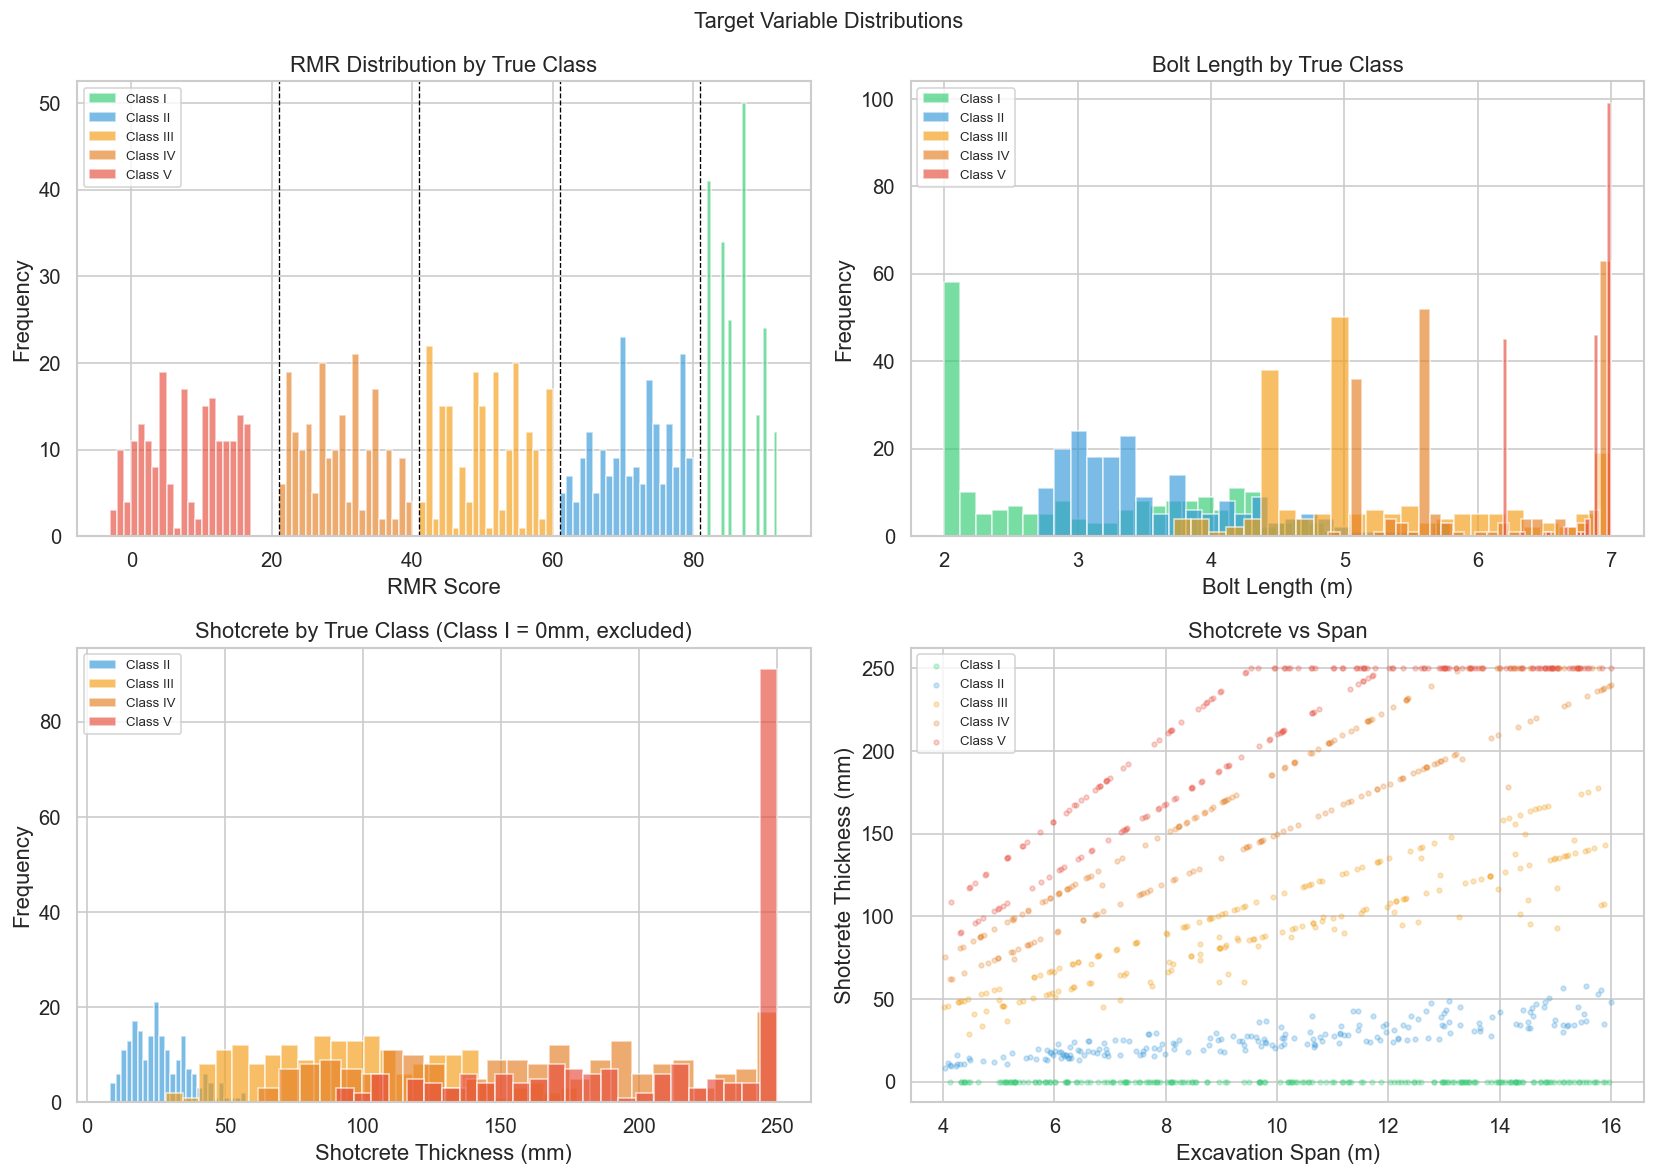

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RMR
ax = axes[0, 0]
for cls in CLASS_ORDER:
    ax.hist(df[df['True_Rock_Class'] == cls]['RMR'],
            bins=20, alpha=0.65, color=CLASS_COLORS[cls], label=f'Class {cls}')
for b in [21, 41, 61, 81]:
    ax.axvline(b, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('RMR Score')
ax.set_ylabel('Frequency')
ax.set_title('RMR Distribution by True Class')
ax.legend(fontsize=8)

# bolt length
ax = axes[0, 1]
for cls in CLASS_ORDER:
    ax.hist(df[df['True_Rock_Class'] == cls]['Bolt_Length_m'],
            bins=25, alpha=0.65, color=CLASS_COLORS[cls], label=f'Class {cls}')
ax.set_xlabel('Bolt Length (m)')
ax.set_ylabel('Frequency')
ax.set_title('Bolt Length by True Class')
ax.legend(fontsize=8)

# shotcrete — skip class I, it's always 0
ax = axes[1, 0]
for cls in ['II', 'III', 'IV', 'V']:
    ax.hist(df[df['True_Rock_Class'] == cls]['Shotcrete_mm'],
            bins=25, alpha=0.65, color=CLASS_COLORS[cls], label=f'Class {cls}')
ax.set_xlabel('Shotcrete Thickness (mm)')
ax.set_ylabel('Frequency')
ax.set_title('Shotcrete by True Class (Class I = 0mm, excluded)')
ax.legend(fontsize=8)

# shotcrete vs span
ax = axes[1, 1]
for cls in CLASS_ORDER:
    s = df[df['True_Rock_Class'] == cls]
    ax.scatter(s['Excavation_Span_m'], s['Shotcrete_mm'],
               alpha=0.25, s=8, color=CLASS_COLORS[cls], label=f'Class {cls}')
ax.set_xlabel('Excavation Span (m)')
ax.set_ylabel('Shotcrete Thickness (mm)')
ax.set_title('Shotcrete vs Span')
ax.legend(fontsize=8)

plt.suptitle('Target Variable Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('fig_targets.png')
plt.show()

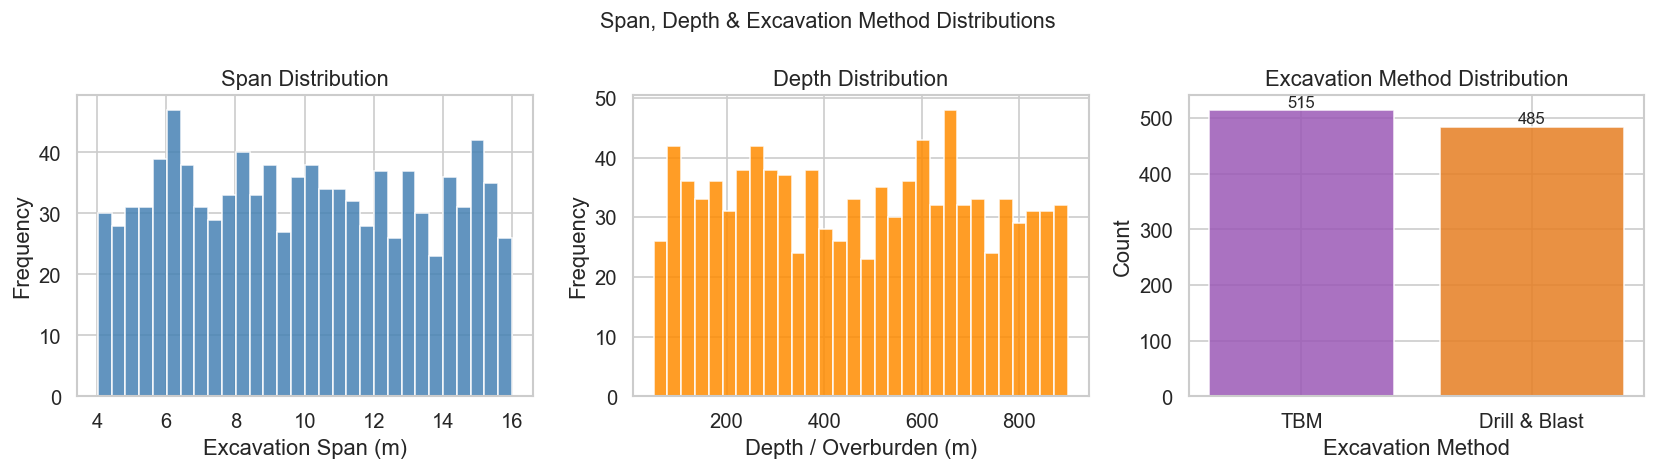

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Excavation_Span_m'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Excavation Span (m)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Span Distribution')

axes[1].hist(df['Depth_m'], bins=30, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Depth / Overburden (m)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Depth Distribution')

method_counts = df['Excavation_Method'].value_counts().rename({0: 'TBM', 1: 'Drill & Blast'})
axes[2].bar(method_counts.index, method_counts.values,
            color=['#9b59b6', '#e67e22'], edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Excavation Method')
axes[2].set_ylabel('Count')
axes[2].set_title('Excavation Method Distribution')
for i, v in enumerate(method_counts.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontsize=10)

plt.suptitle('Span, Depth & Excavation Method Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('fig_features.png')
plt.show()

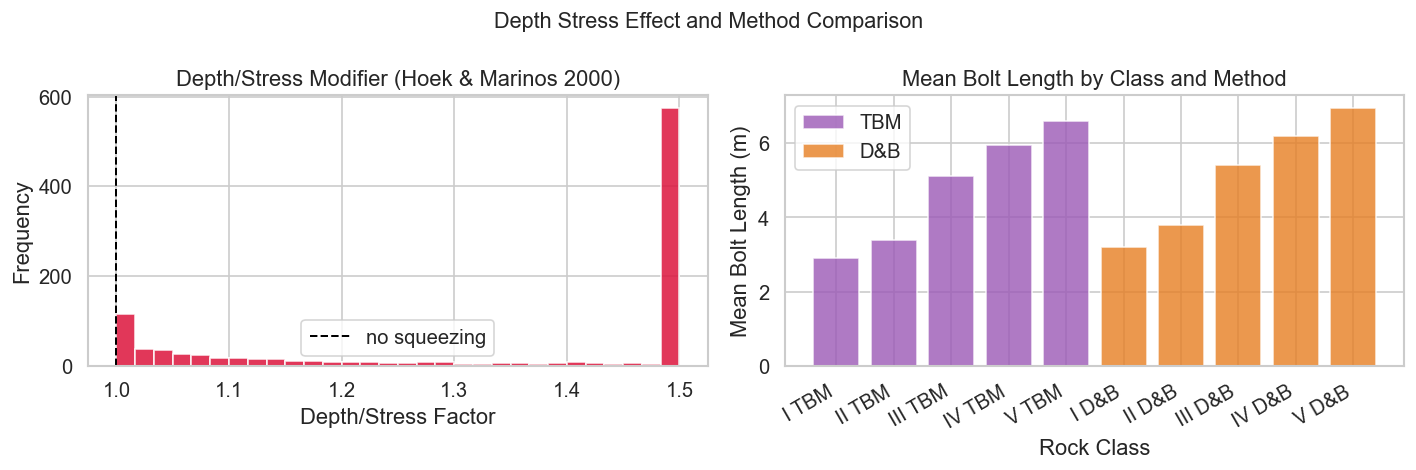

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Depth_factor'], bins=30, color='crimson', edgecolor='white', alpha=0.85)
axes[0].axvline(1.0, color='black', linewidth=1.2, linestyle='--', label='no squeezing')
axes[0].set_xlabel('Depth/Stress Factor')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Depth/Stress Modifier (Hoek & Marinos 2000)')
axes[0].legend()

for method, label, color in [(0, 'TBM', '#9b59b6'), (1, 'D&B', '#e67e22')]:
    means = df[df['Excavation_Method'] == method].groupby('True_Rock_Class')['Bolt_Length_m'].mean()
    axes[1].bar(
        [c + (' TBM' if method == 0 else ' D&B') for c in CLASS_ORDER],
        [means.get(c, 0) for c in CLASS_ORDER],
        color=color, alpha=0.8, edgecolor='white', label=label
    )
axes[1].set_xlabel('Rock Class')
axes[1].set_ylabel('Mean Bolt Length (m)')
axes[1].set_title('Mean Bolt Length by Class and Method')
axes[1].legend()
plt.xticks(rotation=30, ha='right')

plt.suptitle('Depth Stress Effect and Method Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('fig_depth_method.png')
plt.show()

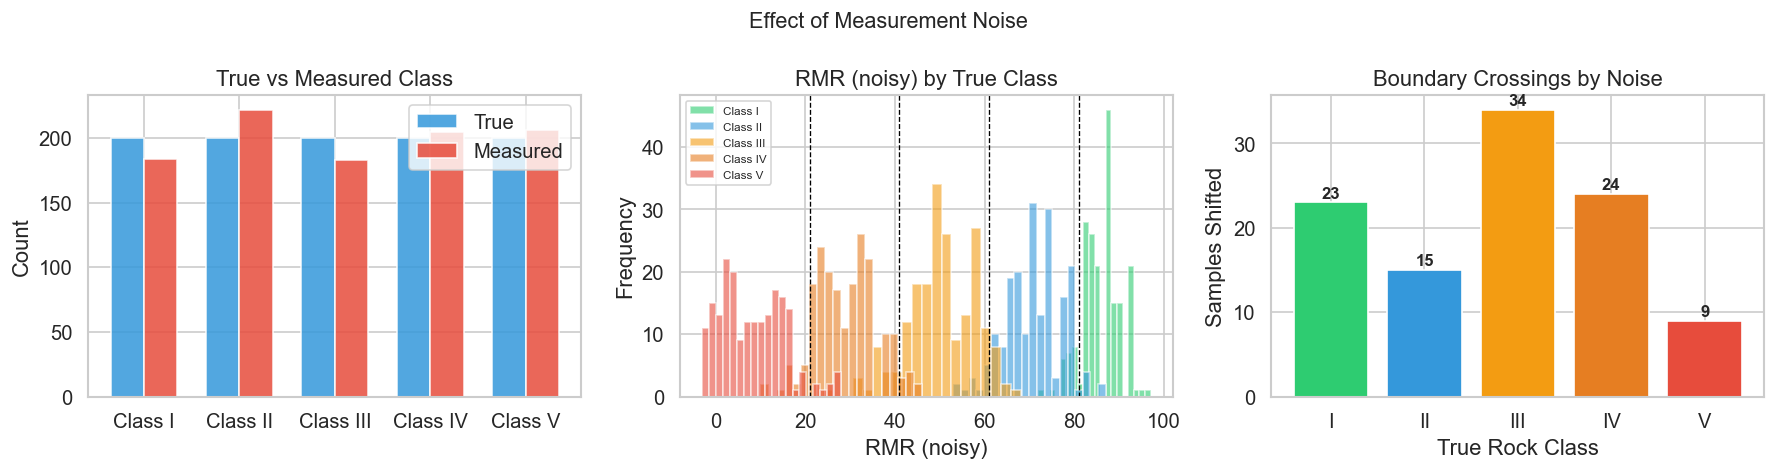

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

true_counts     = df['True_Rock_Class'].value_counts().reindex(CLASS_ORDER)
measured_counts = df['Measured_Rock_Class'].value_counts().reindex(CLASS_ORDER)
x = np.arange(len(CLASS_ORDER))
w = 0.35
axes[0].bar(x - w/2, true_counts.values,     width=w, label='True',     color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, measured_counts.values, width=w, label='Measured', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
axes[0].set_ylabel('Count')
axes[0].set_title('True vs Measured Class')
axes[0].legend()

# recompute RMR from the noisy inputs
rmr_noisy = df.apply(
    lambda r: compute_rmr(r.UCS_MPa, r.RQD_percent, r.Joint_Spacing_m,
                          r.Joint_Condition, r.Groundwater, r.Joint_Orientation_adj), axis=1
)
for cls in CLASS_ORDER:
    axes[1].hist(rmr_noisy[df['True_Rock_Class'] == cls],
                 bins=20, alpha=0.6, color=CLASS_COLORS[cls], label=f'Class {cls}')
for b in [21, 41, 61, 81]:
    axes[1].axvline(b, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('RMR (noisy)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('RMR (noisy) by True Class')
axes[1].legend(fontsize=7)

shifted_per_class = (
    df[df['True_Rock_Class'] != df['Measured_Rock_Class']]
    .groupby('True_Rock_Class').size()
    .reindex(CLASS_ORDER, fill_value=0)
)
bars = axes[2].bar(CLASS_ORDER, shifted_per_class.values,
                   color=[CLASS_COLORS[c] for c in CLASS_ORDER], edgecolor='white')
for bar, v in zip(bars, shifted_per_class.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(v), ha='center', fontsize=10, fontweight='bold')
axes[2].set_xlabel('True Rock Class')
axes[2].set_ylabel('Samples Shifted')
axes[2].set_title('Boundary Crossings by Noise')

plt.suptitle('Effect of Measurement Noise', fontsize=13)
plt.tight_layout()
plt.savefig('fig_noise_effect.png')
plt.show()

In [29]:
# class IV shifts the most — RMR 21-40 is a narrow band, easy to push across
# class I barely moves, plenty of headroom above 81
shifted = (df['True_Rock_Class'] != df['Measured_Rock_Class']).sum()
print(f'total crossings: {shifted} / {len(df)} = {shifted/len(df)*100:.1f}%')
print(df[df['True_Rock_Class'] != df['Measured_Rock_Class']].groupby('True_Rock_Class').size())

total crossings: 105 / 1000 = 10.5%
True_Rock_Class
I      23
II     15
III    34
IV     24
V       9
dtype: int64


## 8. Correlation Analysis

checking which inputs actually correlate with each target


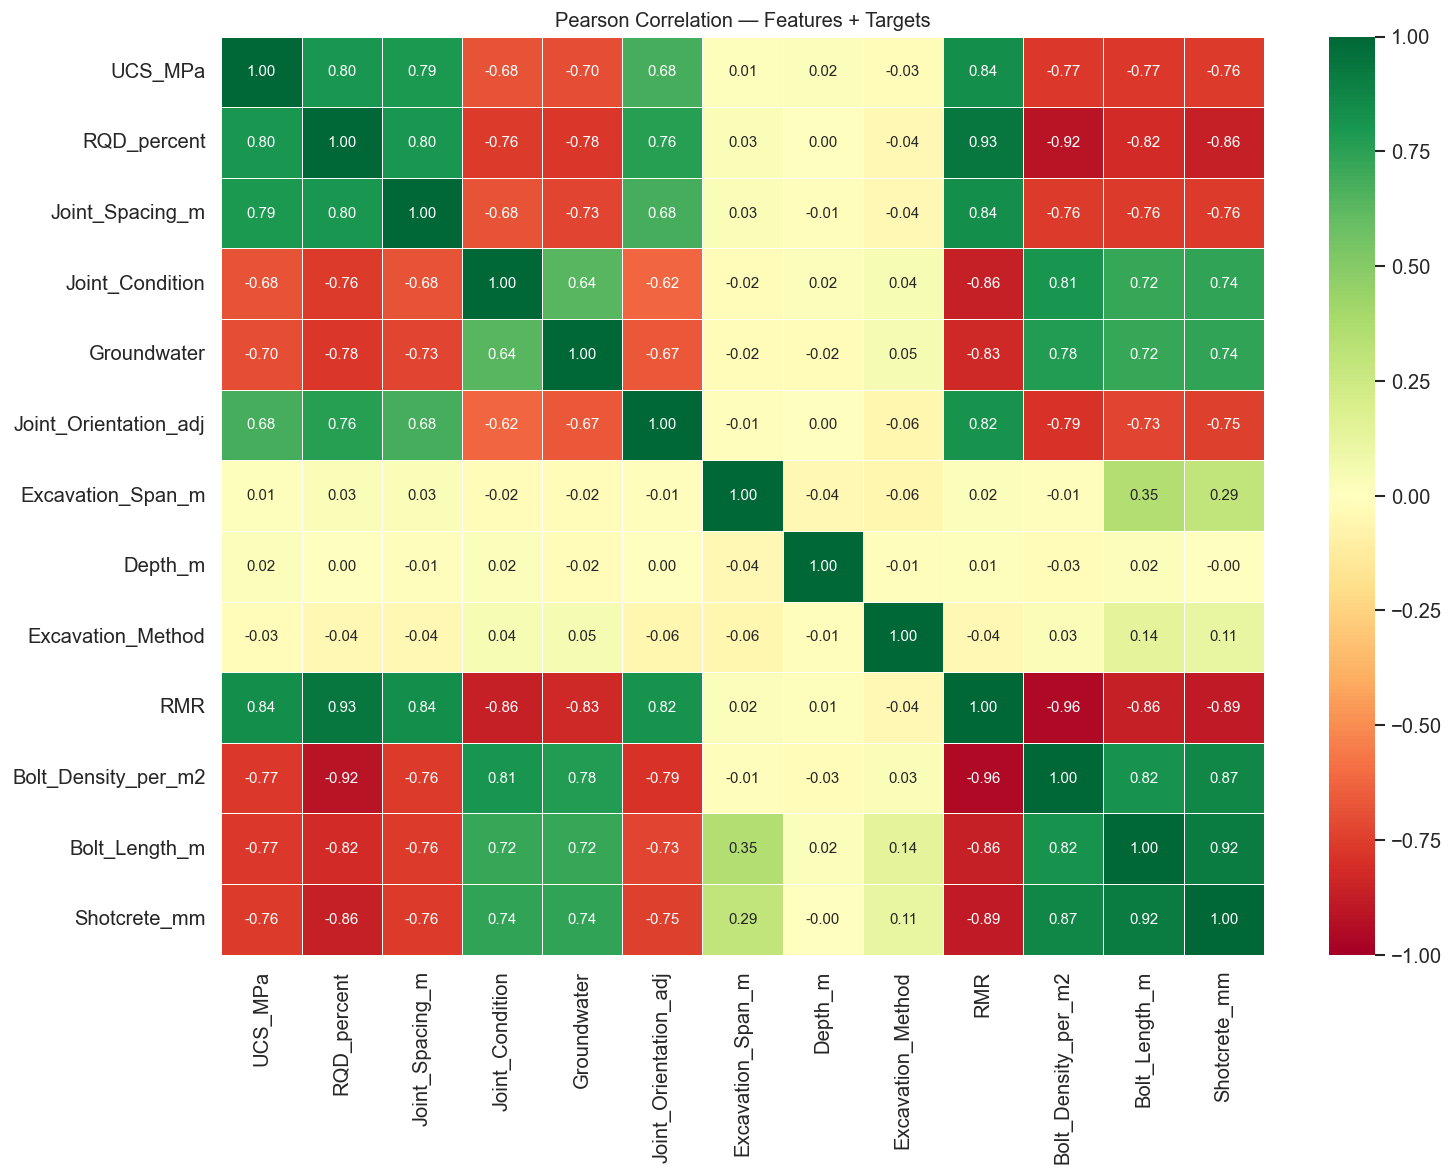

In [25]:
numeric_cols = FEATURE_COLS + TARGET_COLS
corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 9})
ax.set_title('Pearson Correlation — Features + Targets', fontsize=12)
plt.tight_layout()
plt.savefig('fig_correlation.png')
plt.show()

## 9. Save


In [30]:
OUTPUT_COLS = [
    'UCS_MPa', 'RQD_percent', 'Joint_Spacing_m', 'Joint_Condition','Groundwater', 'Joint_Orientation_adj',
    'Excavation_Span_m', 'Depth_m', 'Excavation_Method',
    'RMR', 'True_Rock_Class', 'Measured_Rock_Class',
    'Bolt_Density_per_m2', 'Bolt_Length_m', 'Shotcrete_mm',
    'UCS_clean', 'RQD_clean', 'JS_clean', 'Depth_factor',
]

df_out = df[OUTPUT_COLS]
df_out.to_csv('rmr_dataset.csv', index=False)

print(f'saved rmr_dataset.csv  —  {len(df_out)} rows, {len(OUTPUT_COLS)} cols')
df_out.head()


saved rmr_dataset.csv  —  1000 rows, 19 cols


,UCS_MPa,RQD_percent,Joint_Spacing_m,Joint_Condition,Groundwater,Joint_Orientation_adj,Excavation_Span_m,Depth_m,Excavation_Method,RMR,True_Rock_Class,Measured_Rock_Class,Bolt_Density_per_m2,Bolt_Length_m,Shotcrete_mm,UCS_clean,RQD_clean,JS_clean,Depth_factor
0,207.89,88.69,1.6430,1,2,0,15.71,697.0,0,84,I,I,0.0,4.33,0.0,216.09,88.78,1.8303,1.042
1,218.46,85.46,1.2301,1,2,0,13.93,586.9,0,82,I,I,0.0,3.82,0.0,223.41,88.87,1.0727,1.030
2,114.45,88.73,1.5975,1,2,-2,15.61,327.0,1,82,I,I,0.0,4.79,0.0,106.57,83.09,1.6197,1.045
3,169.92,100.00,1.6843,1,2,0,13.99,734.0,1,92,I,I,0.0,4.28,0.0,165.57,96.65,1.6403,1.040
4,129.48,85.85,1.7546,1,1,-2,13.18,589.5,1,82,I,I,0.0,4.17,0.0,120.97,82.29,1.6021,1.107
